In [1]:
from opal.opal import load_dataset

ds = load_dataset('./RingMultiBunch/', fname='RingMultiBunch.h5')

In [2]:
print ( ds )


	H5 dataset.

	Number of steps: 4

	Available step attributes (42):

	#sigma              
	#varepsilon         
	#varepsilon-geom    
	AZIMUTH             
	B-head              
	B-ref               
	B-tail              
	CHARGE              
	E-head              
	E-ref               
	E-tail              
	ELEVATION           
	ENERGY              
	GlobalTrackStep     
	LOCAL               
	LocalTrackStep      
	MASS                
	NumBunch            
	OPAL_flavour        
	REFPR               
	REFPT               
	REFPZ               
	REFR                
	REFTHETA            
	REFZ                
	RMSP                
	RMSX                
	RefPartP            
	RefPartR            
	SPOS                
	Step                
	SteptoLastInj       
	TIME                
	centroid            
	dE                  
	maxP                
	maxX                
	minP                
	minX                
	spos-head           
	spos-ref            
	spos-tail           


	Ava

In [3]:
from opal.visualization.styles import jupyter

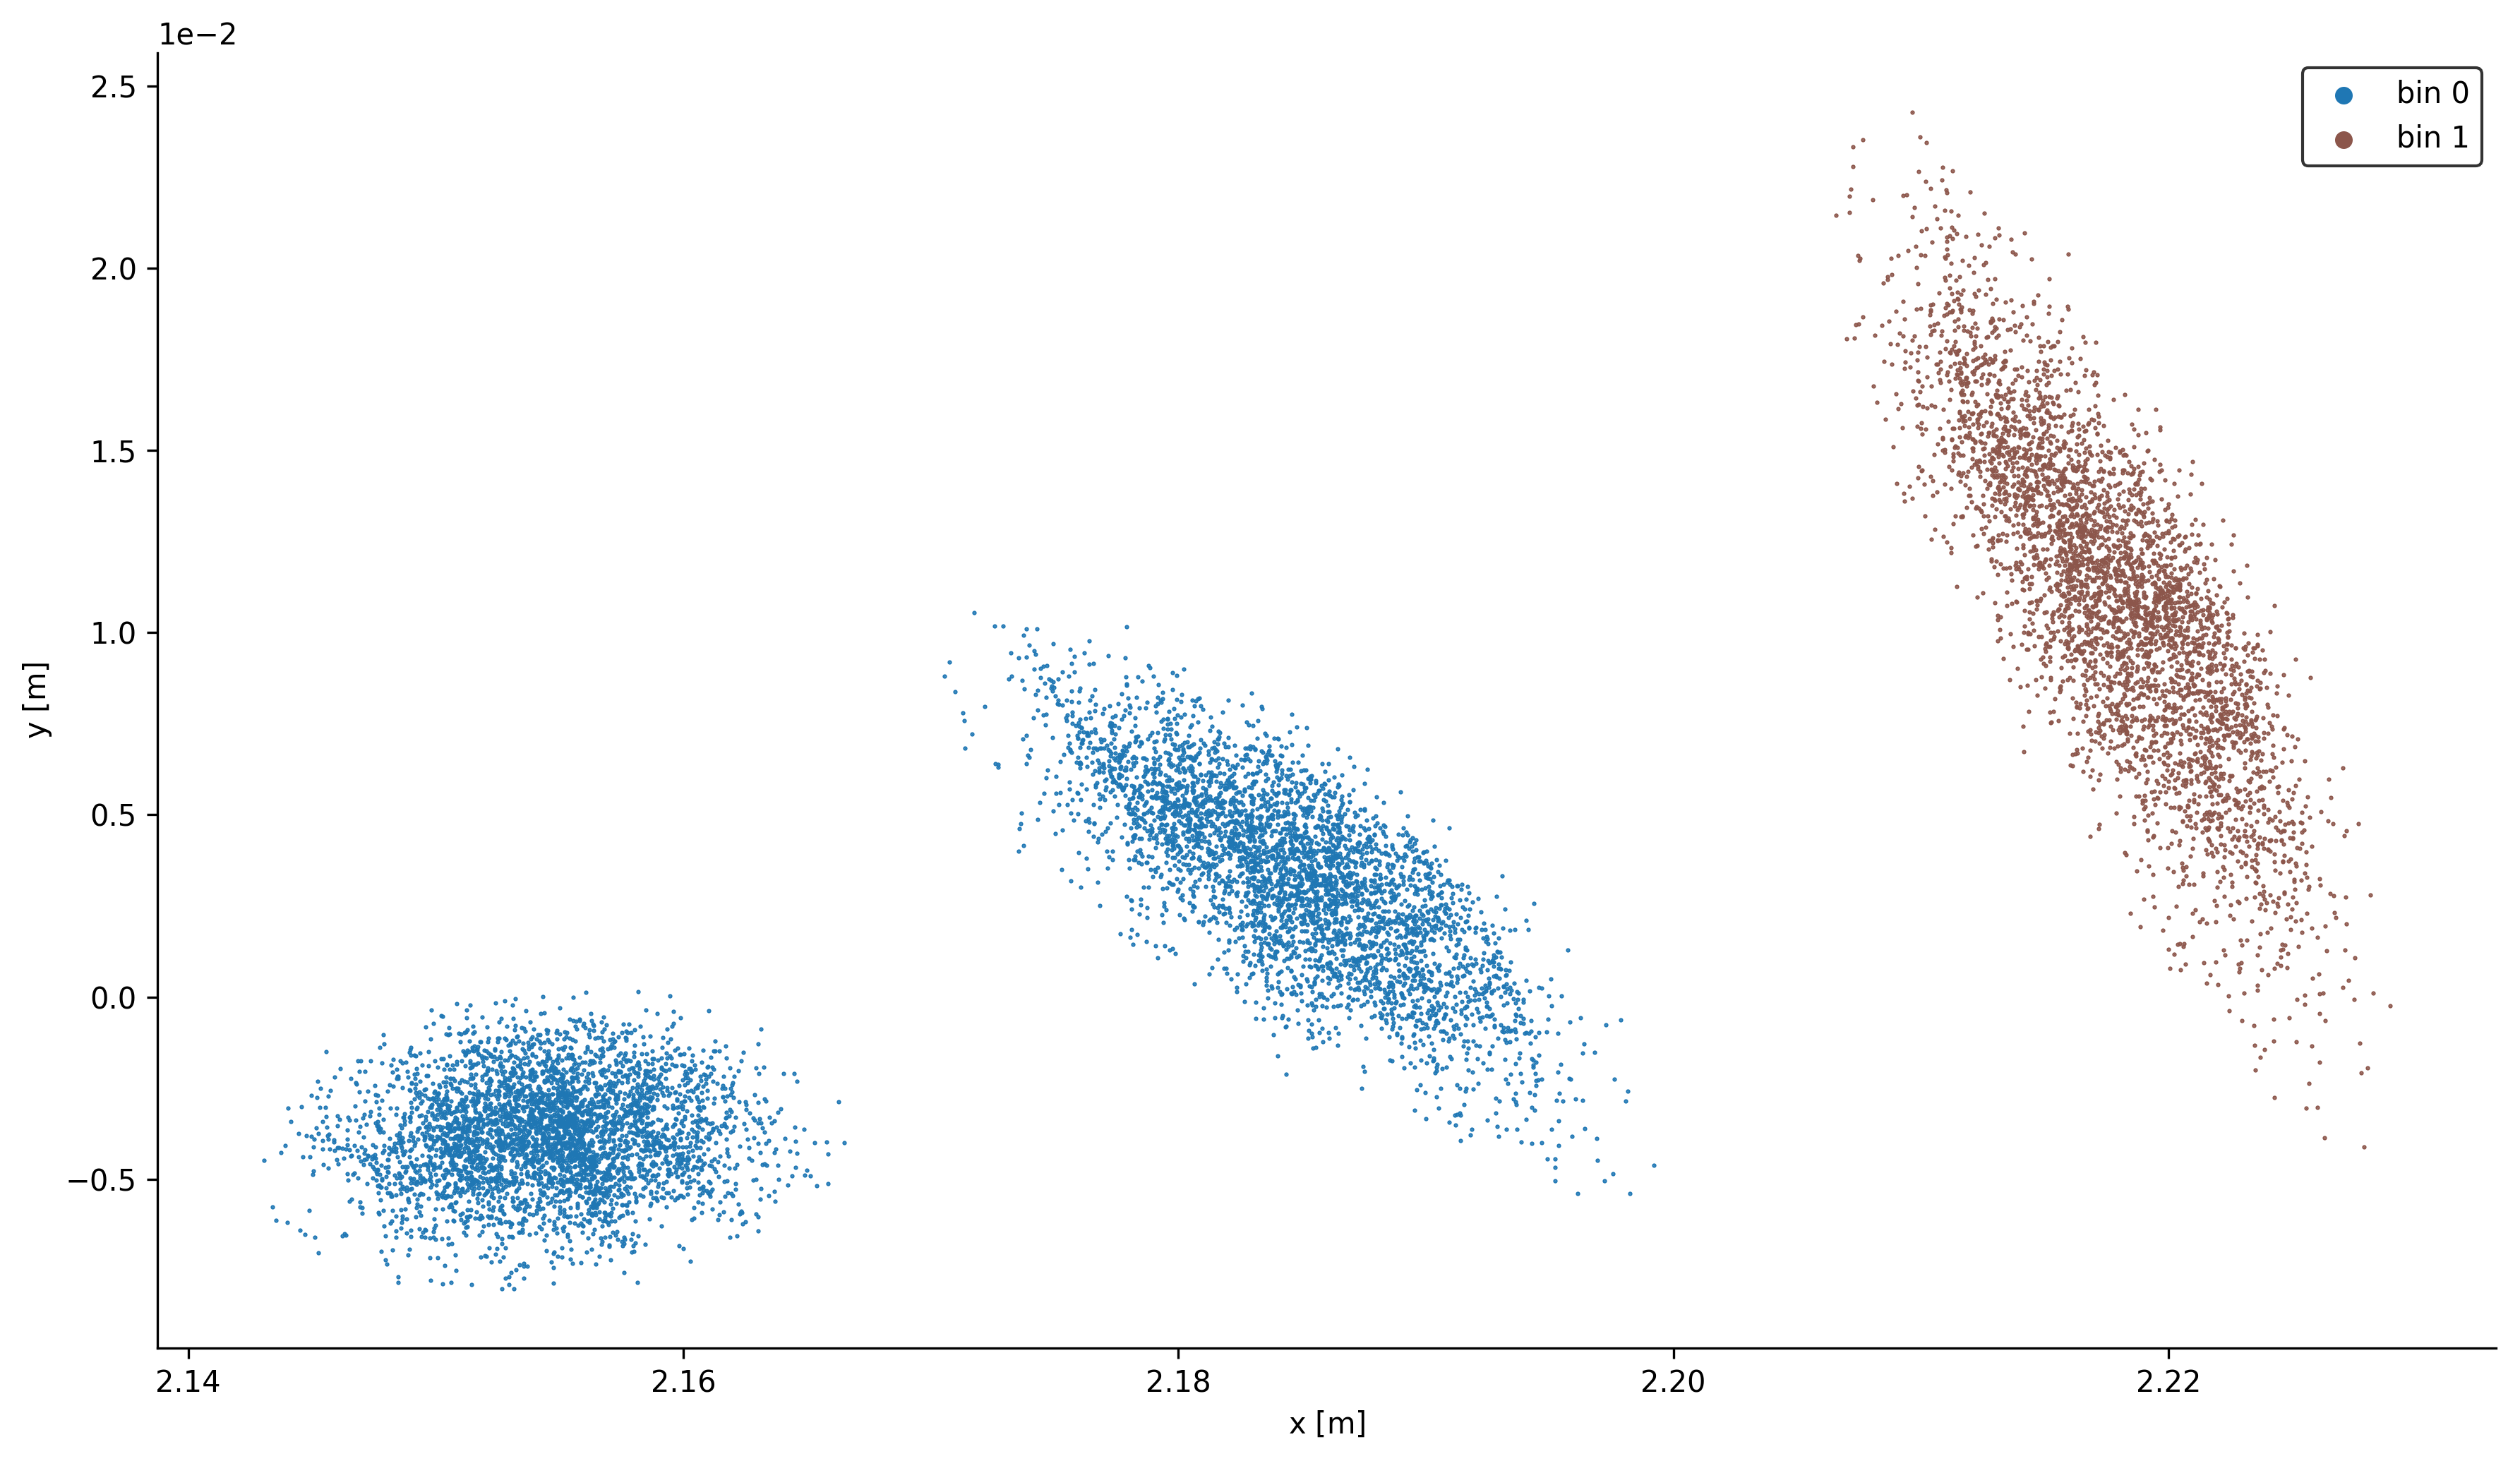

In [4]:
plt = ds.plot_phase_space('x', 'y', xsci=True, ysci=True, step=3, bins=[0, 1])

plt.legend(['bin 0', 'bin 1'], markerscale=10)

plt.show()

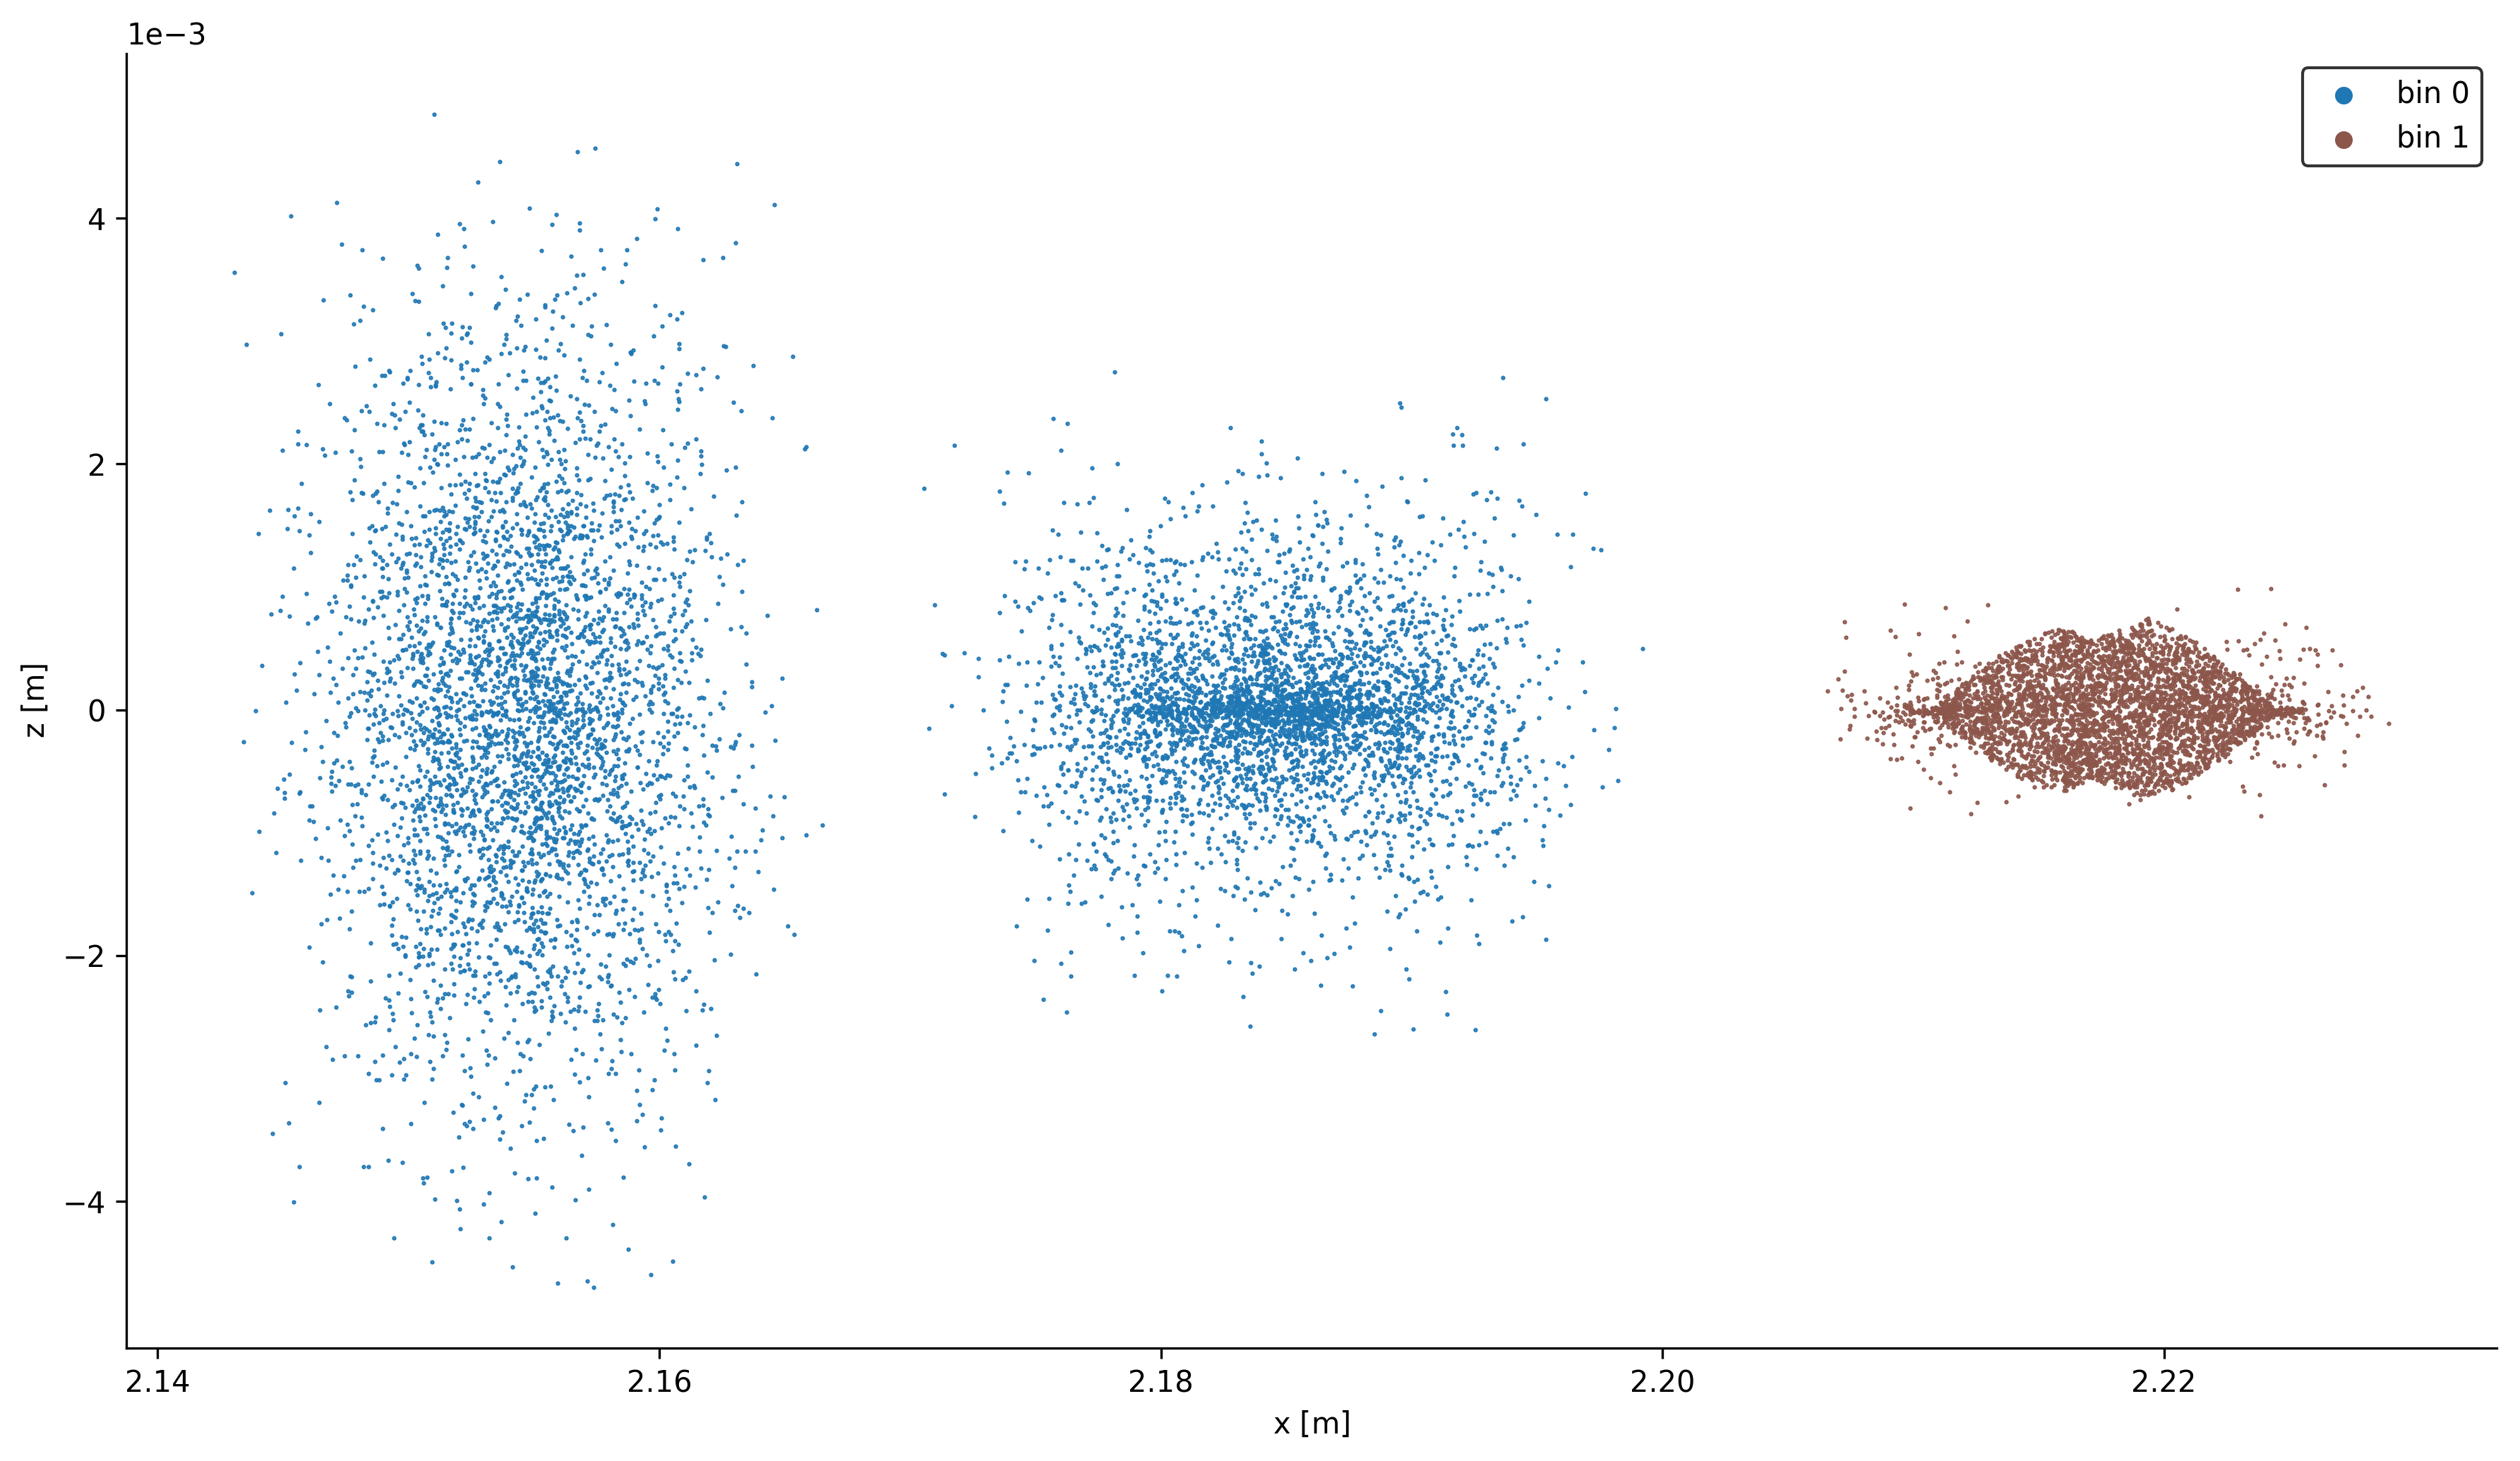

In [5]:
plt = ds.plot_phase_space('x', 'z', xsci=True, ysci=True, step=3, bins=[0, 1])

plt.legend(['bin 0', 'bin 1'], markerscale=10)

plt.show()

In [6]:
try:
    print ( "Central moment:  " + str(ds.moment('x', k=1, bin=1, step=3)) )
    
    print ( "Arithmetic mean: " + str(ds.mean('x', bin=1, step=3)) )
    
    print ( "Skewness:        " + str(ds.skew('x', bin=1, step=3)) )
    
    print ( "Kurtosis:        " + str(ds.kurtosis('x', bin=1, step=3)) )
except Exception as e:
    print ( e )

Central moment:  0.0
Arithmetic mean: 2.2177577034146974
Skewness:        -0.07187704928121756
Kurtosis:        -0.07187704928121756


In [7]:
minima = ds.find_beams('x', step=3)[0]

print ( minima )

[2.1430608605003947, 2.1645333893538004, 2.198889435519249, 2.228950975914017]


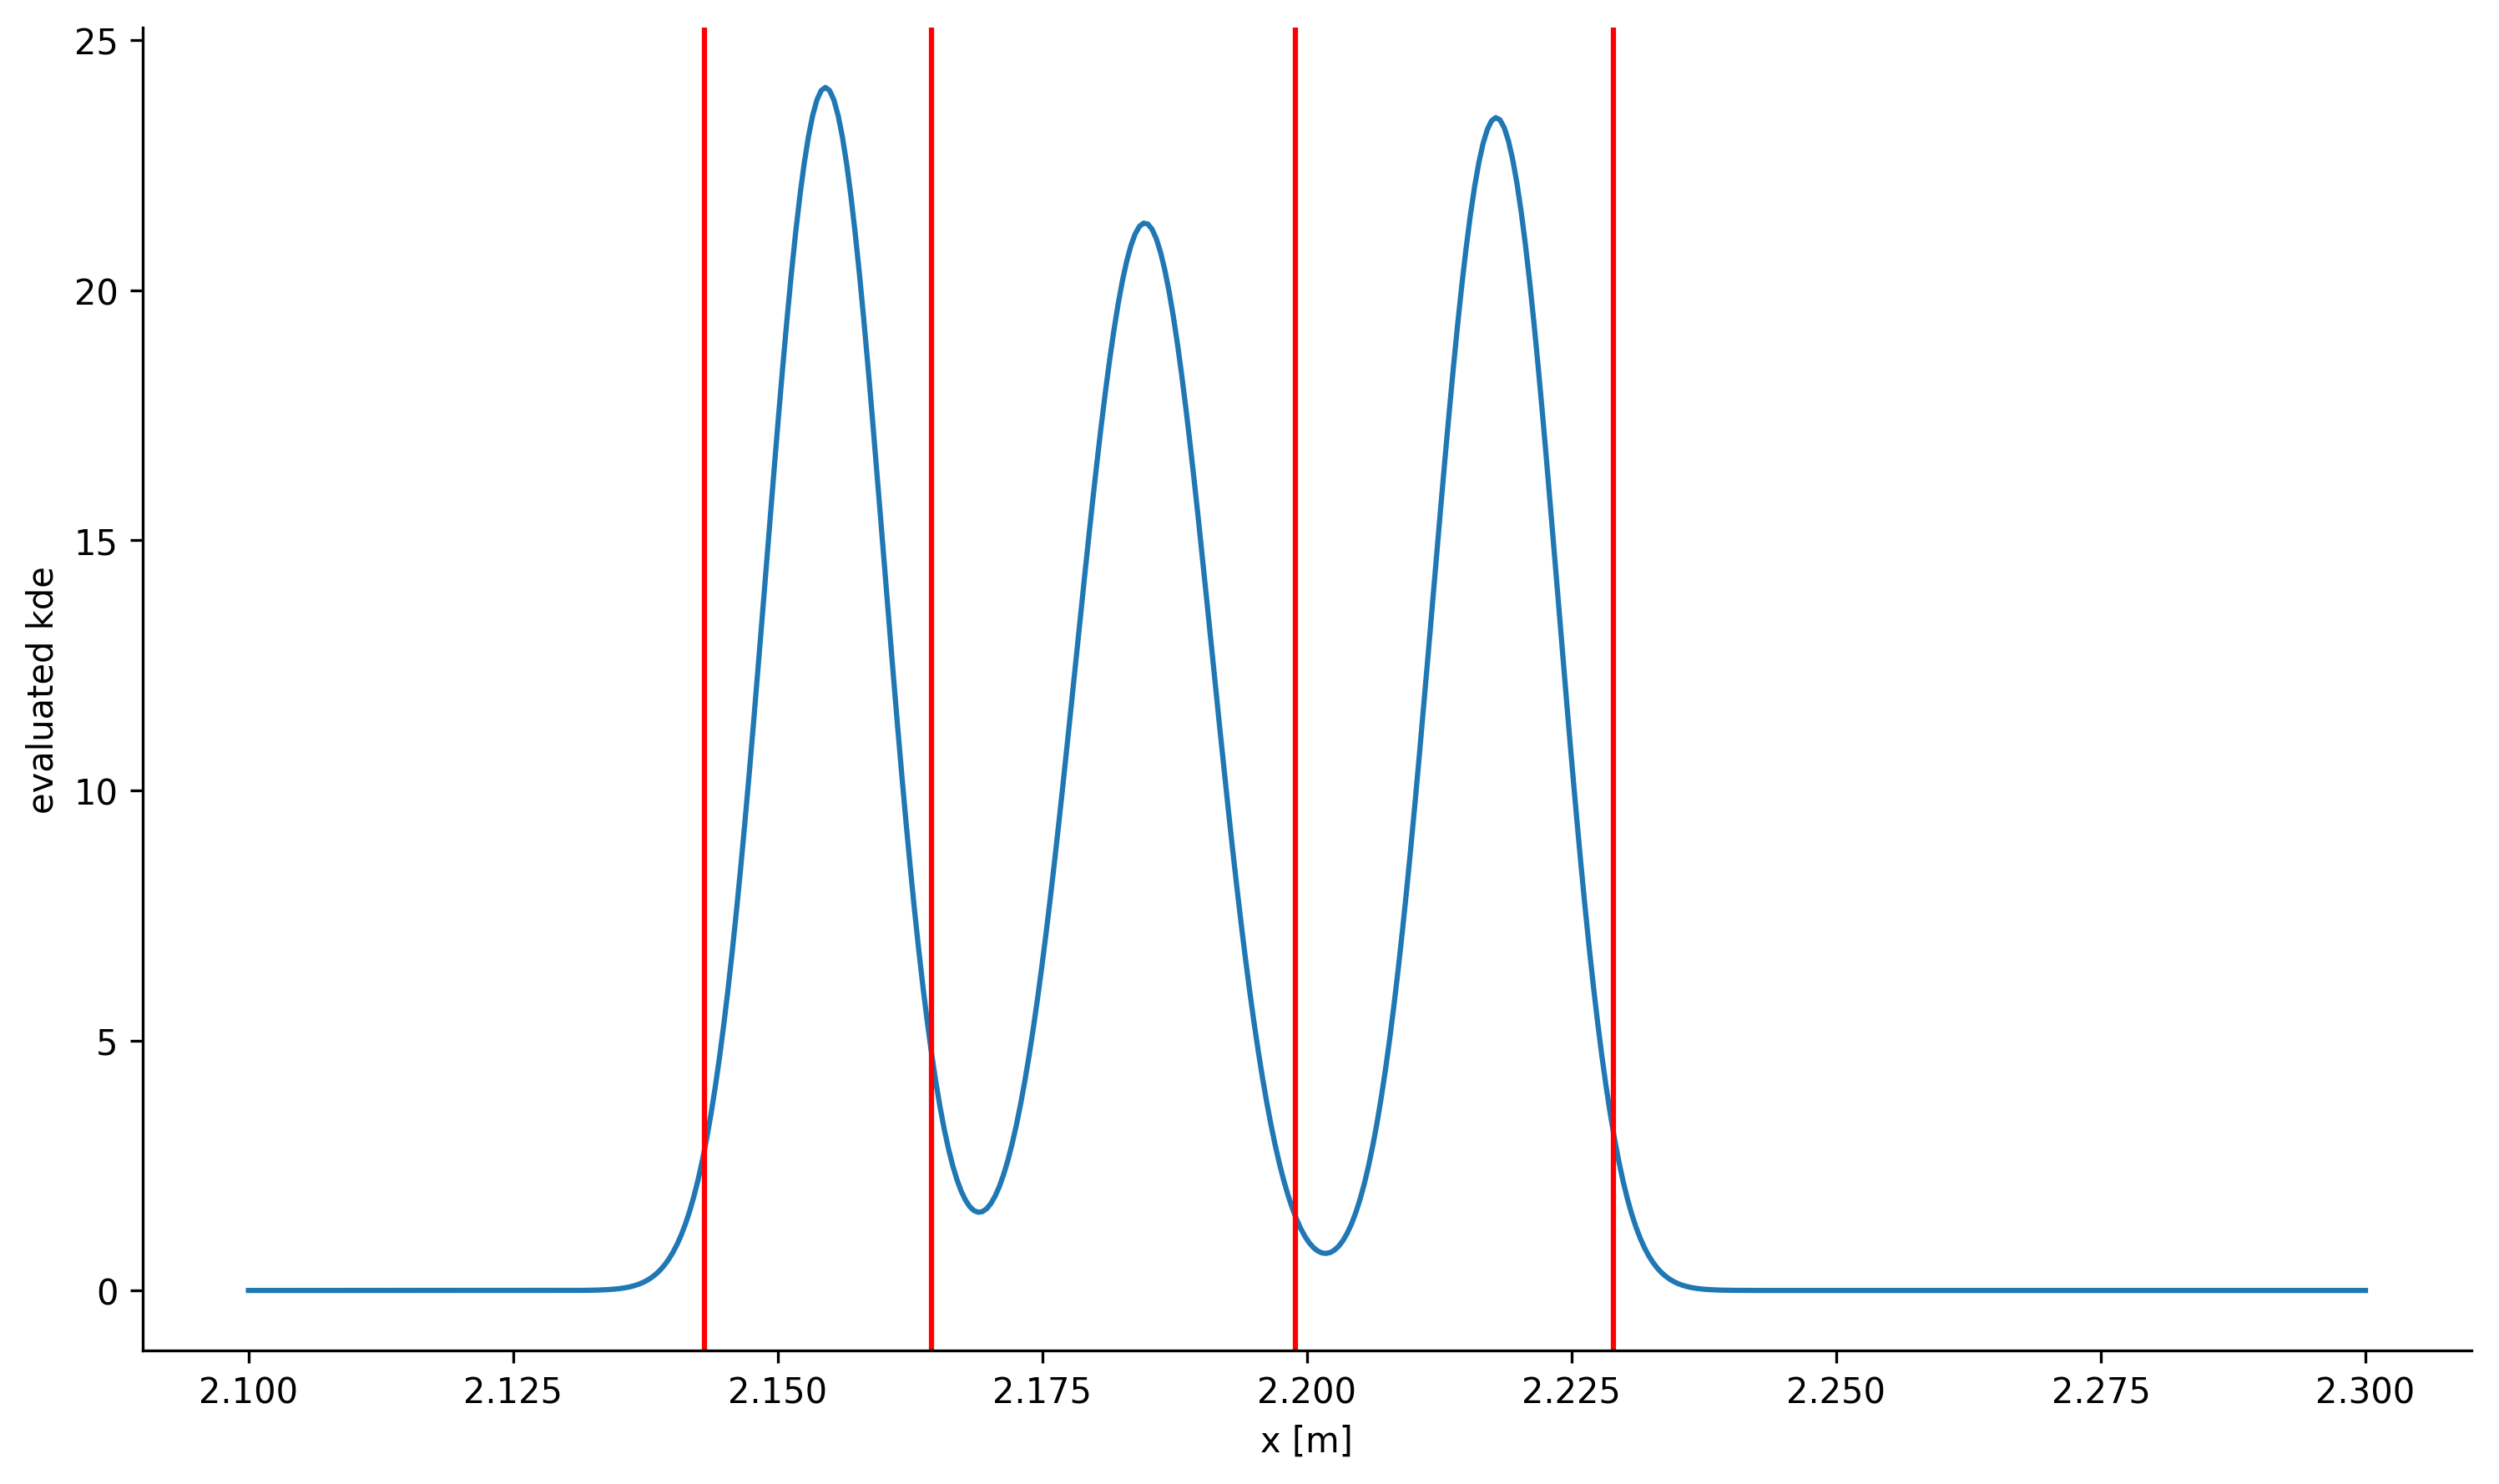

In [8]:
kde = ds.gaussian_kde('x', step=3)
import numpy as np

points = np.linspace(2.1, 2.3, 500)

pdf = kde.pdf(points)

plt.plot(points, pdf)
plt.xlabel('x [m]')
plt.ylabel('evaluated kde')

for m in minima:
    plt.axvline(m, color='r')
plt.show()

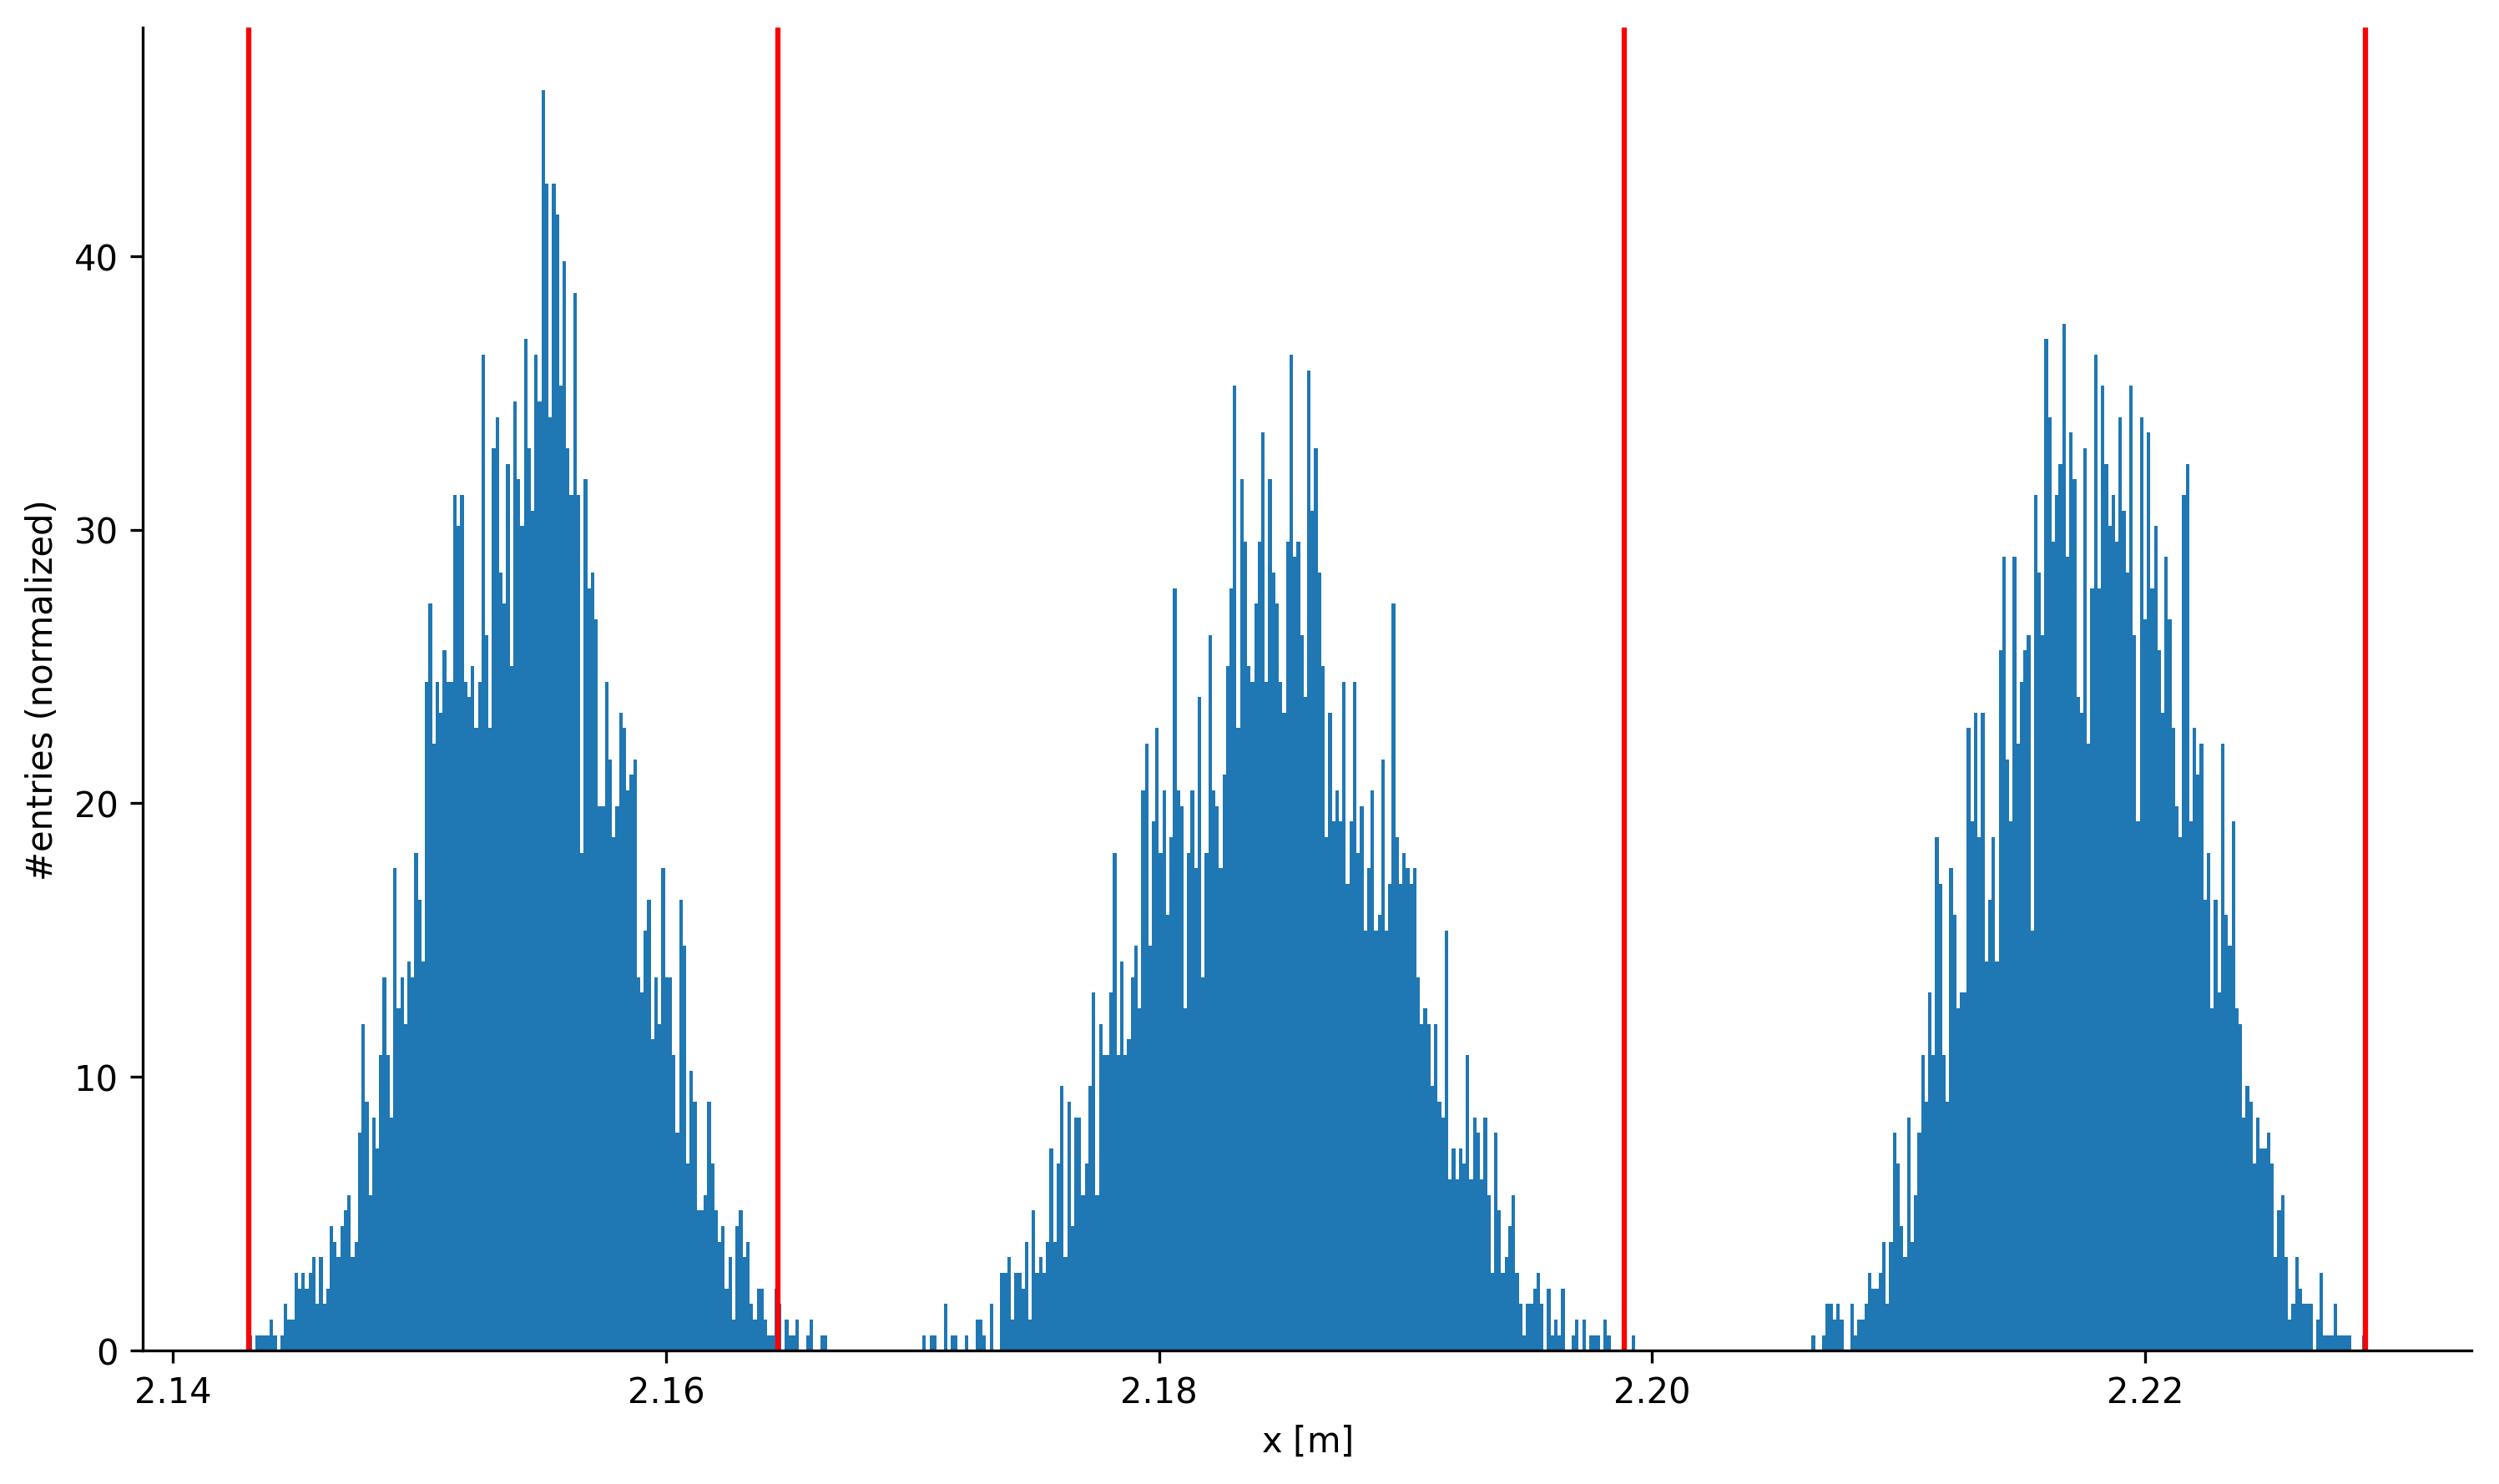

In [9]:
plt = ds.plot_histogram('x', step=3, bins=600)

for m in minima:
    plt.axvline(m, color='r')
plt.show()

In [10]:
try:
    data, _ = ds.get_beam('x', step=3, k=1)
    hist, _ = ds.histogram(data, bins=18, density=True)
    plt.plot(hist)
    plt.xlabel('bin')
    plt.ylabel('#entries (normalized)')
    
    plt.show()
except Exception as e:
    print ( e )

unhashable type: 'numpy.ndarray'


In [11]:
from opal.analysis import impl_beam
from opal.analysis.Statistics import Statistics

try:
    print ( "#particles:          " + str(len(data)) )
    
    print ( "Central moment:      " + str(ds.moment('x', k=1) ) )
    
    print ( "Arithmetic mean:     " + str(ds.mean('x') ) )
    
    print ( "Skewness:            " + str(ds.skew('x') ) )
    
    print ( "Kurtosis:            " + str(ds.kurtosis('x') ) )
    
    print ( "Kurtosis (Wangler):  " + str(ds.halo_ellipsoidal_beam('x')) )
    
except Exception as e:
    print ( e )

#particles:          4108
Central moment:      0.0
Arithmetic mean:     2.129973117937309
Skewness:            -0.006735504373180921
Kurtosis:            -0.006735504373180921
Kurtosis (Wangler):  0.6486949767809009


In [12]:
#plt = plot_classification(dsets[0], xvar='x', yvar='y', value=400, step=3)

#plt.show()

/home/matthias/blub/test/lib/python3.5/site-packages/seaborn-0.9.0-py3.5.egg/seaborn/axisgrid.py:1672: UserWarning:

The `size` parameter has been renamed to `height`; pleaes update your code.



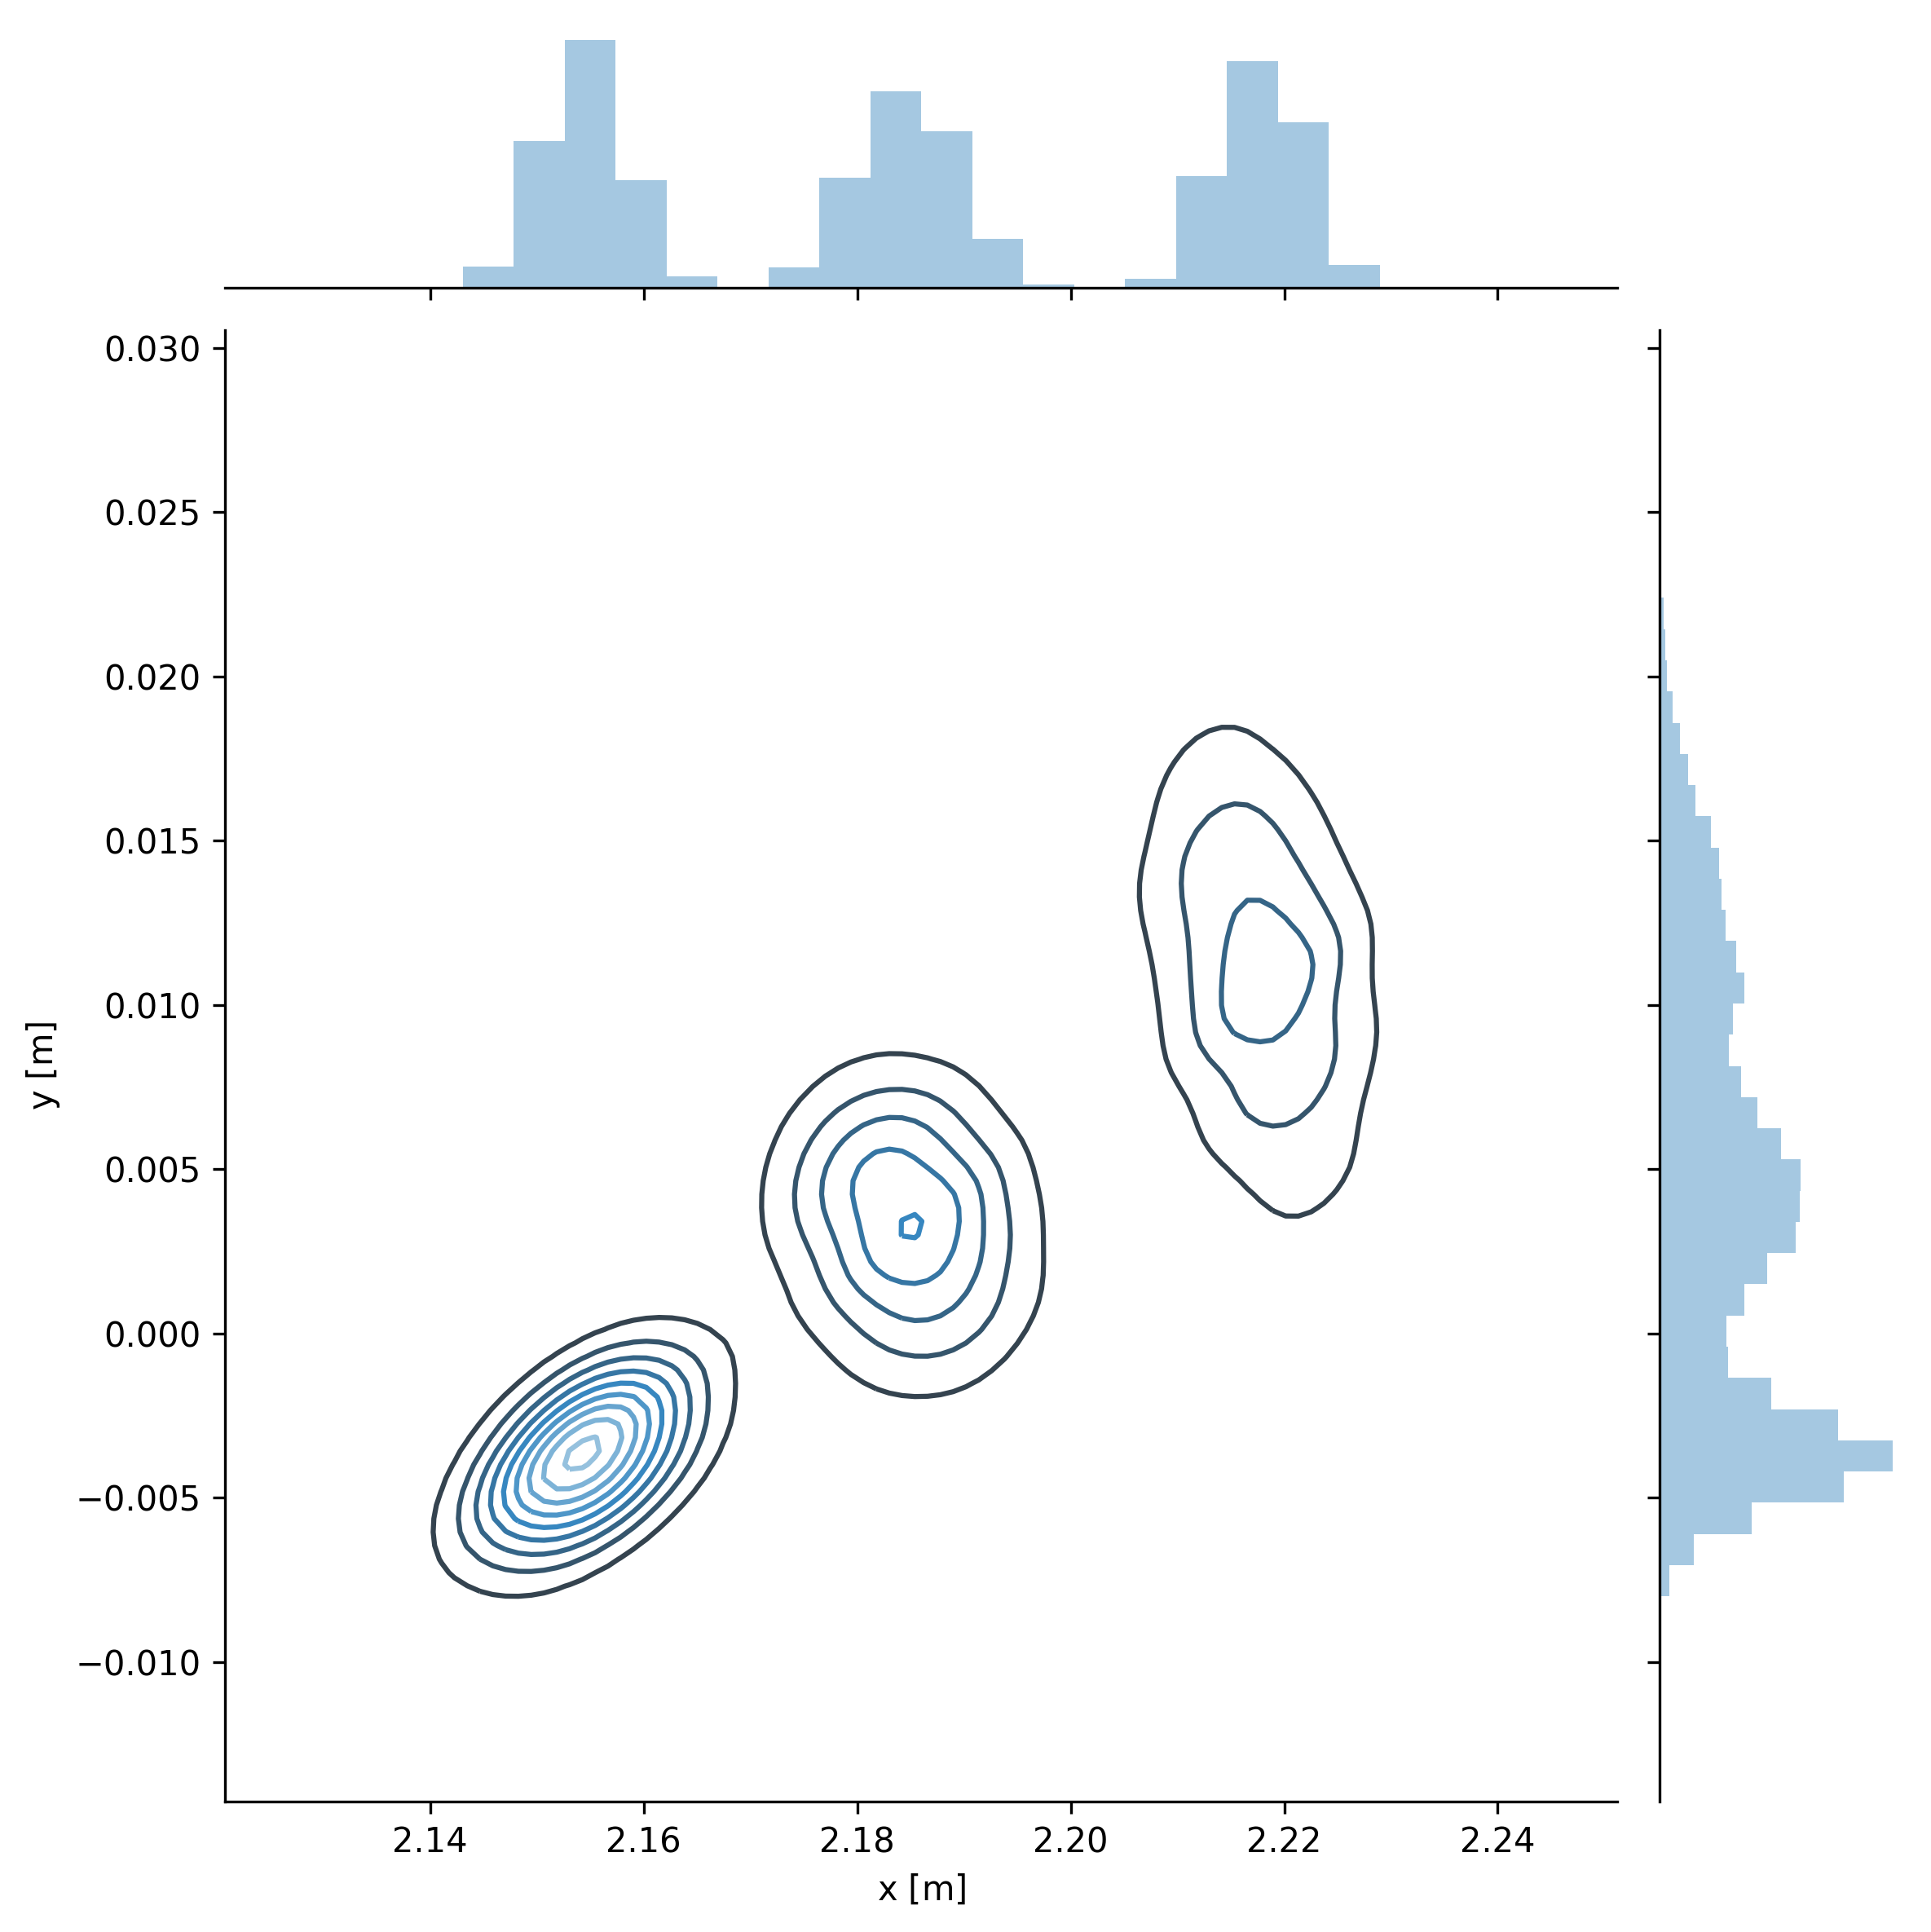

In [13]:
plt = ds.plot_joint(xvar='x', yvar='y', join='contour', step=3)

plt.show()

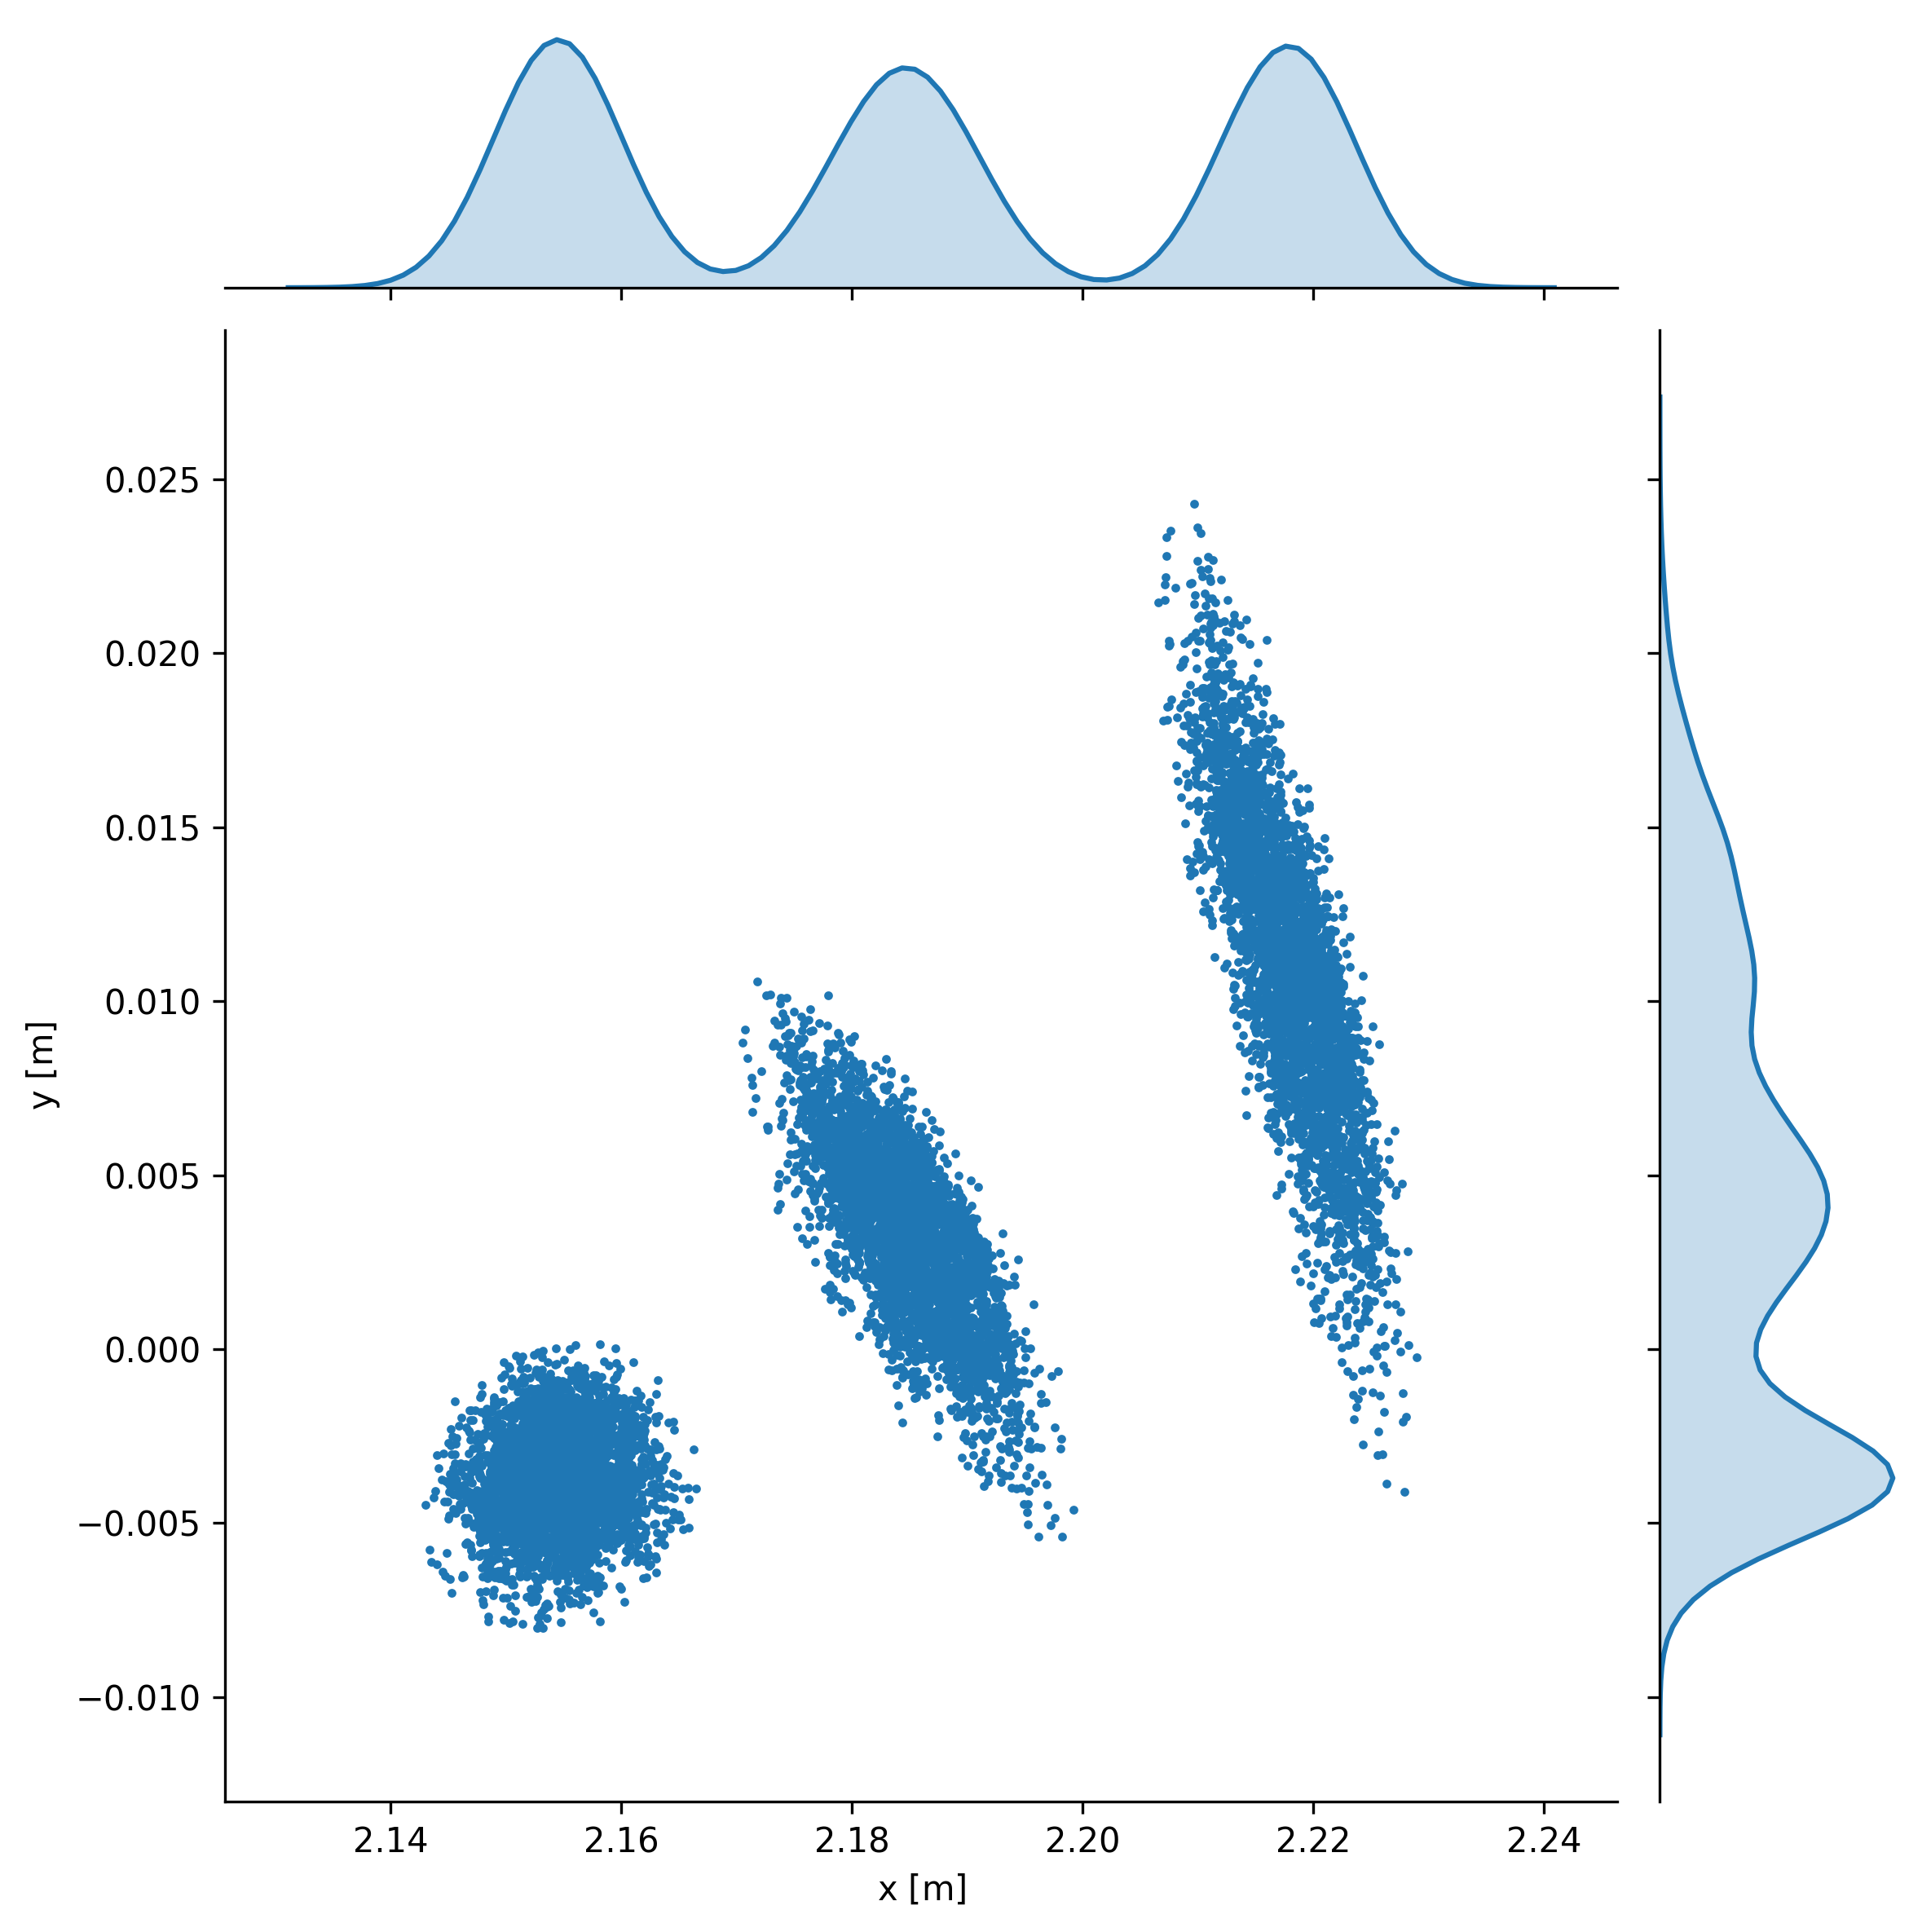

In [14]:
plt = ds.plot_joint(xvar='x', yvar='y', join='scatter', marginals='kde', step=3)

plt.show()

In [15]:
help(ds.plot_joint)

Help on method plot_joint in module opal.visualization.H5Plotter:

plot_joint(xvar, yvar, join, **kwargs) method of opal.datasets.H5Dataset.H5Dataset instance
    Do a joint plot (marginals + contour / scatter)
    
    Parameters
    ----------
    ds      (DatasetBase)       dataset
    xvar    (str)               x-axis variable to consider
    yvar    (str)               y-axis variable to consider
    join    (str)               'all', 'contour' or 'scatter'
    
    Optional parameters
    -------------------
    step        (int)           of dataset
    see also                    help(impl_plots.plot_joint)
    
    Returns
    -------
    a matplotlib.pyplot handle



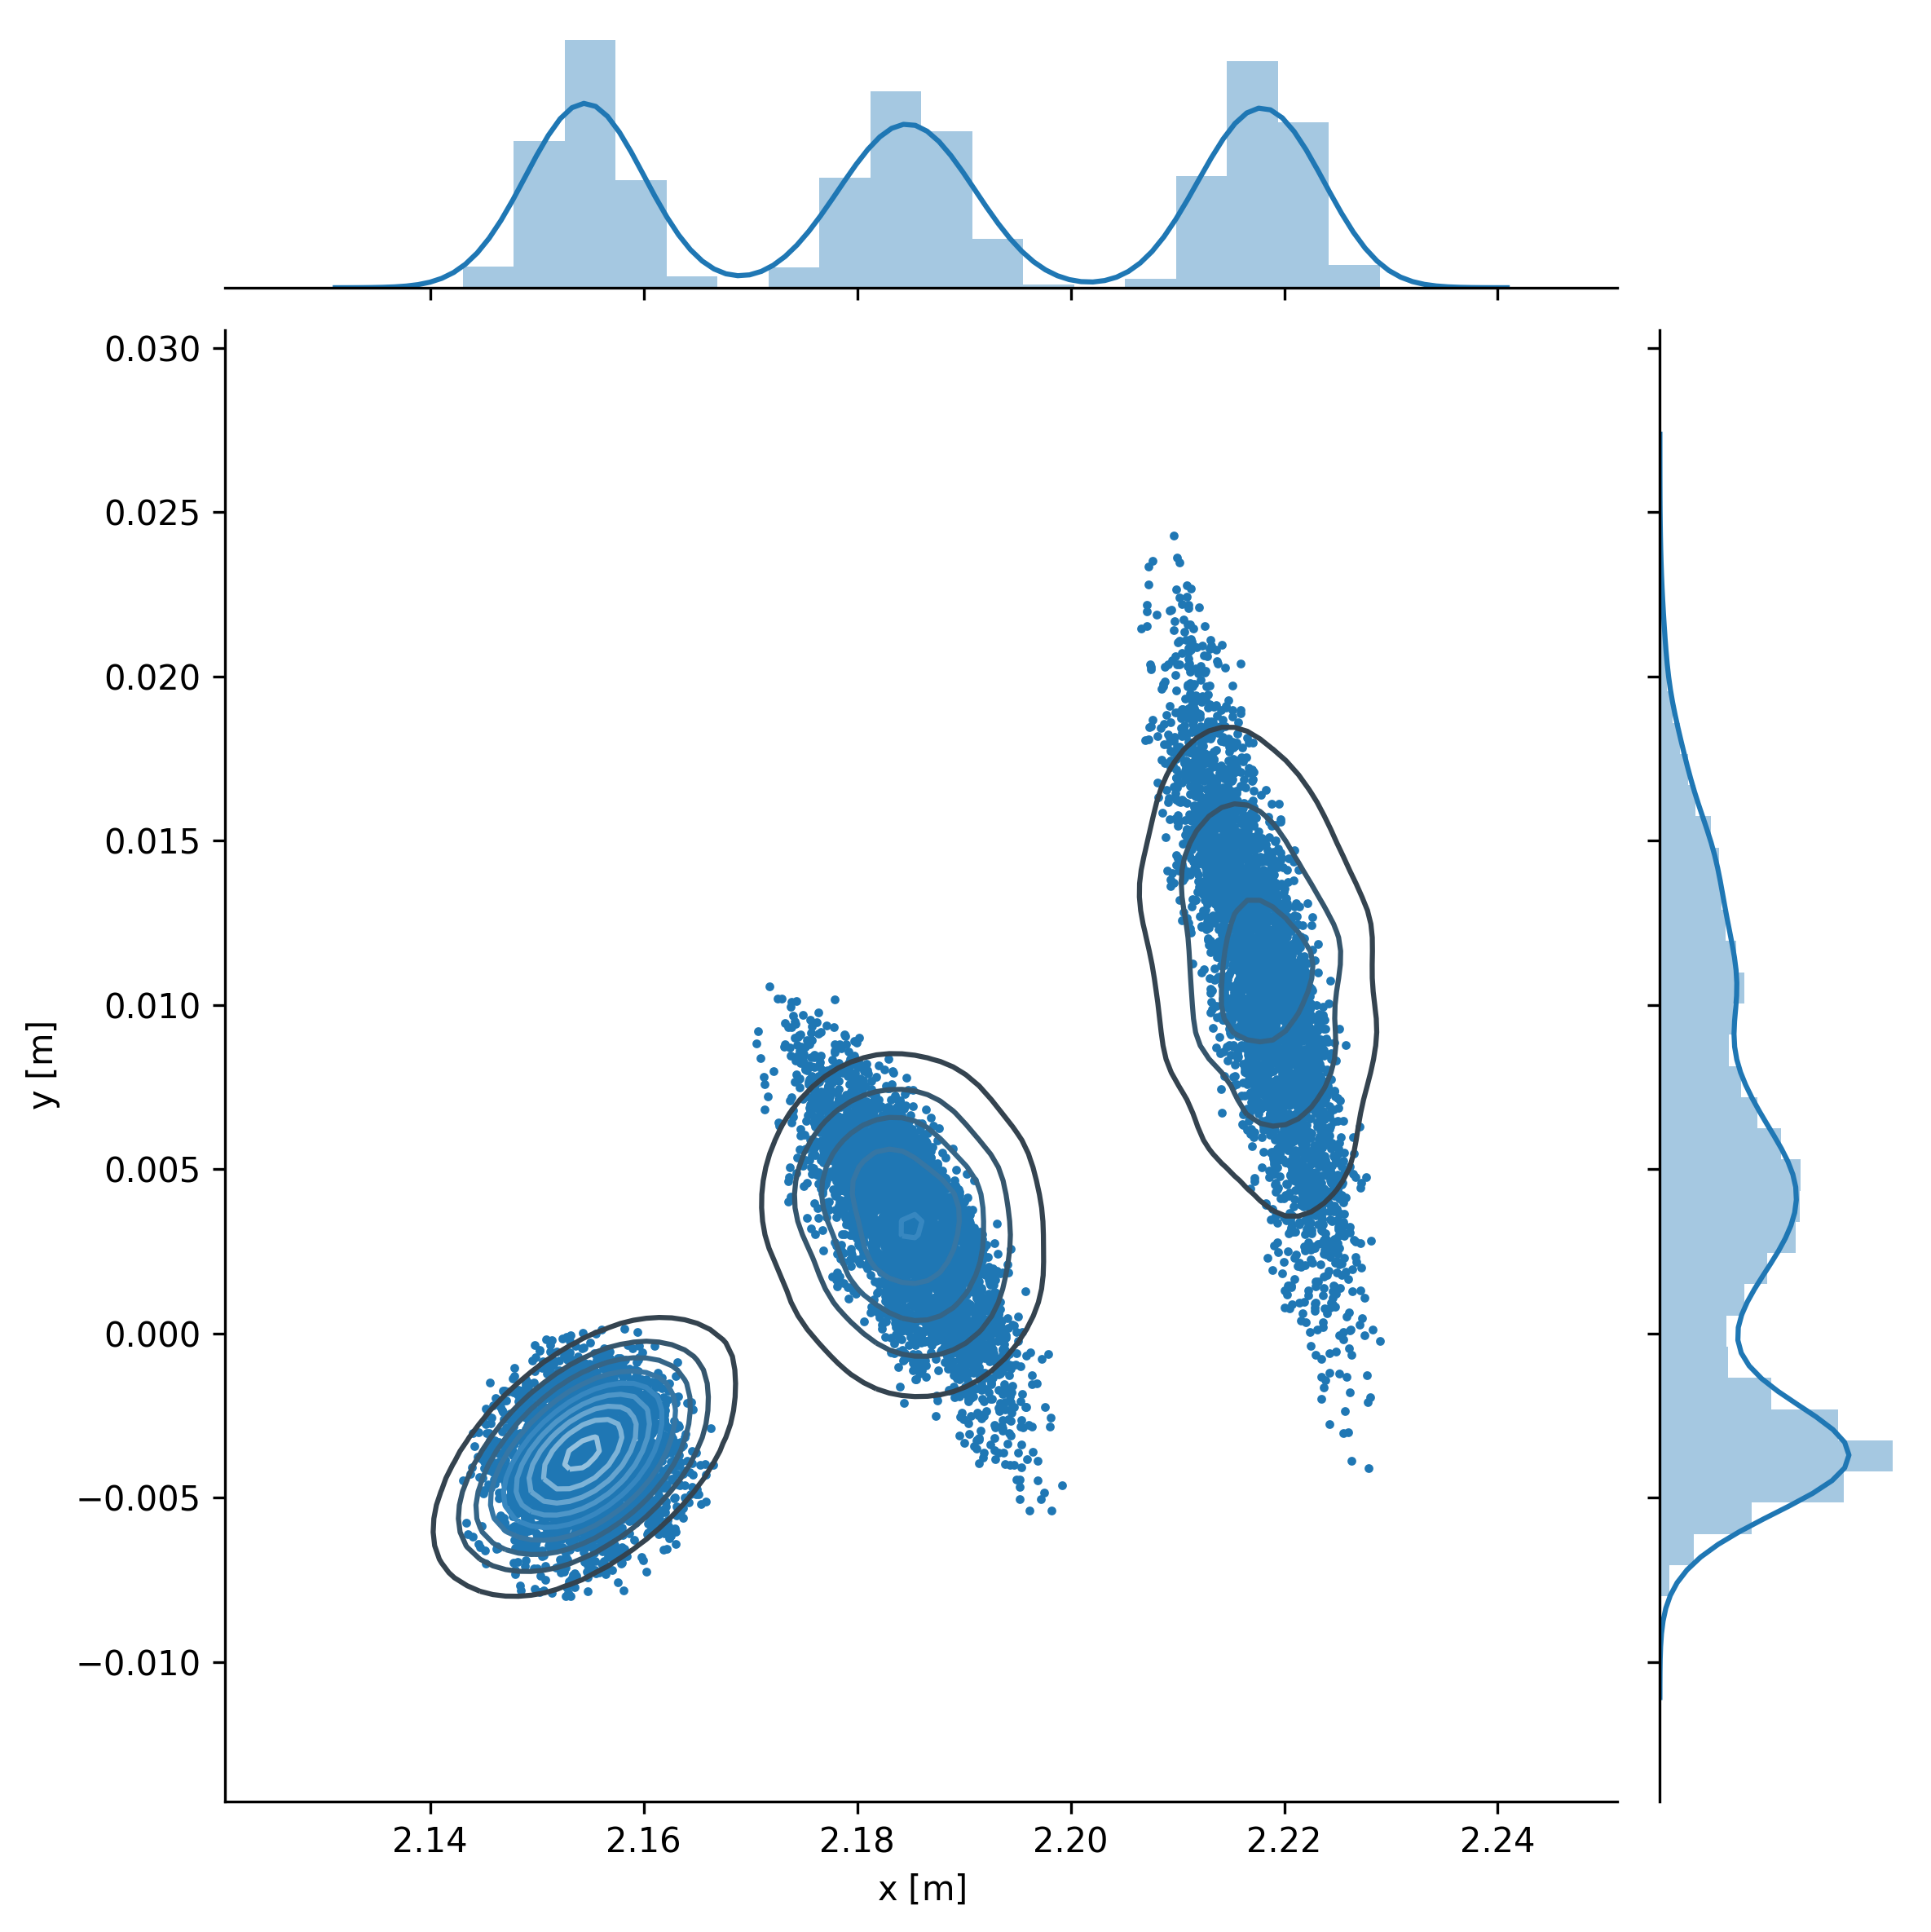

In [16]:
plt = ds.plot_joint(xvar='x', yvar='y', join='all', marginals='kde+hist', step=3)

plt.show()

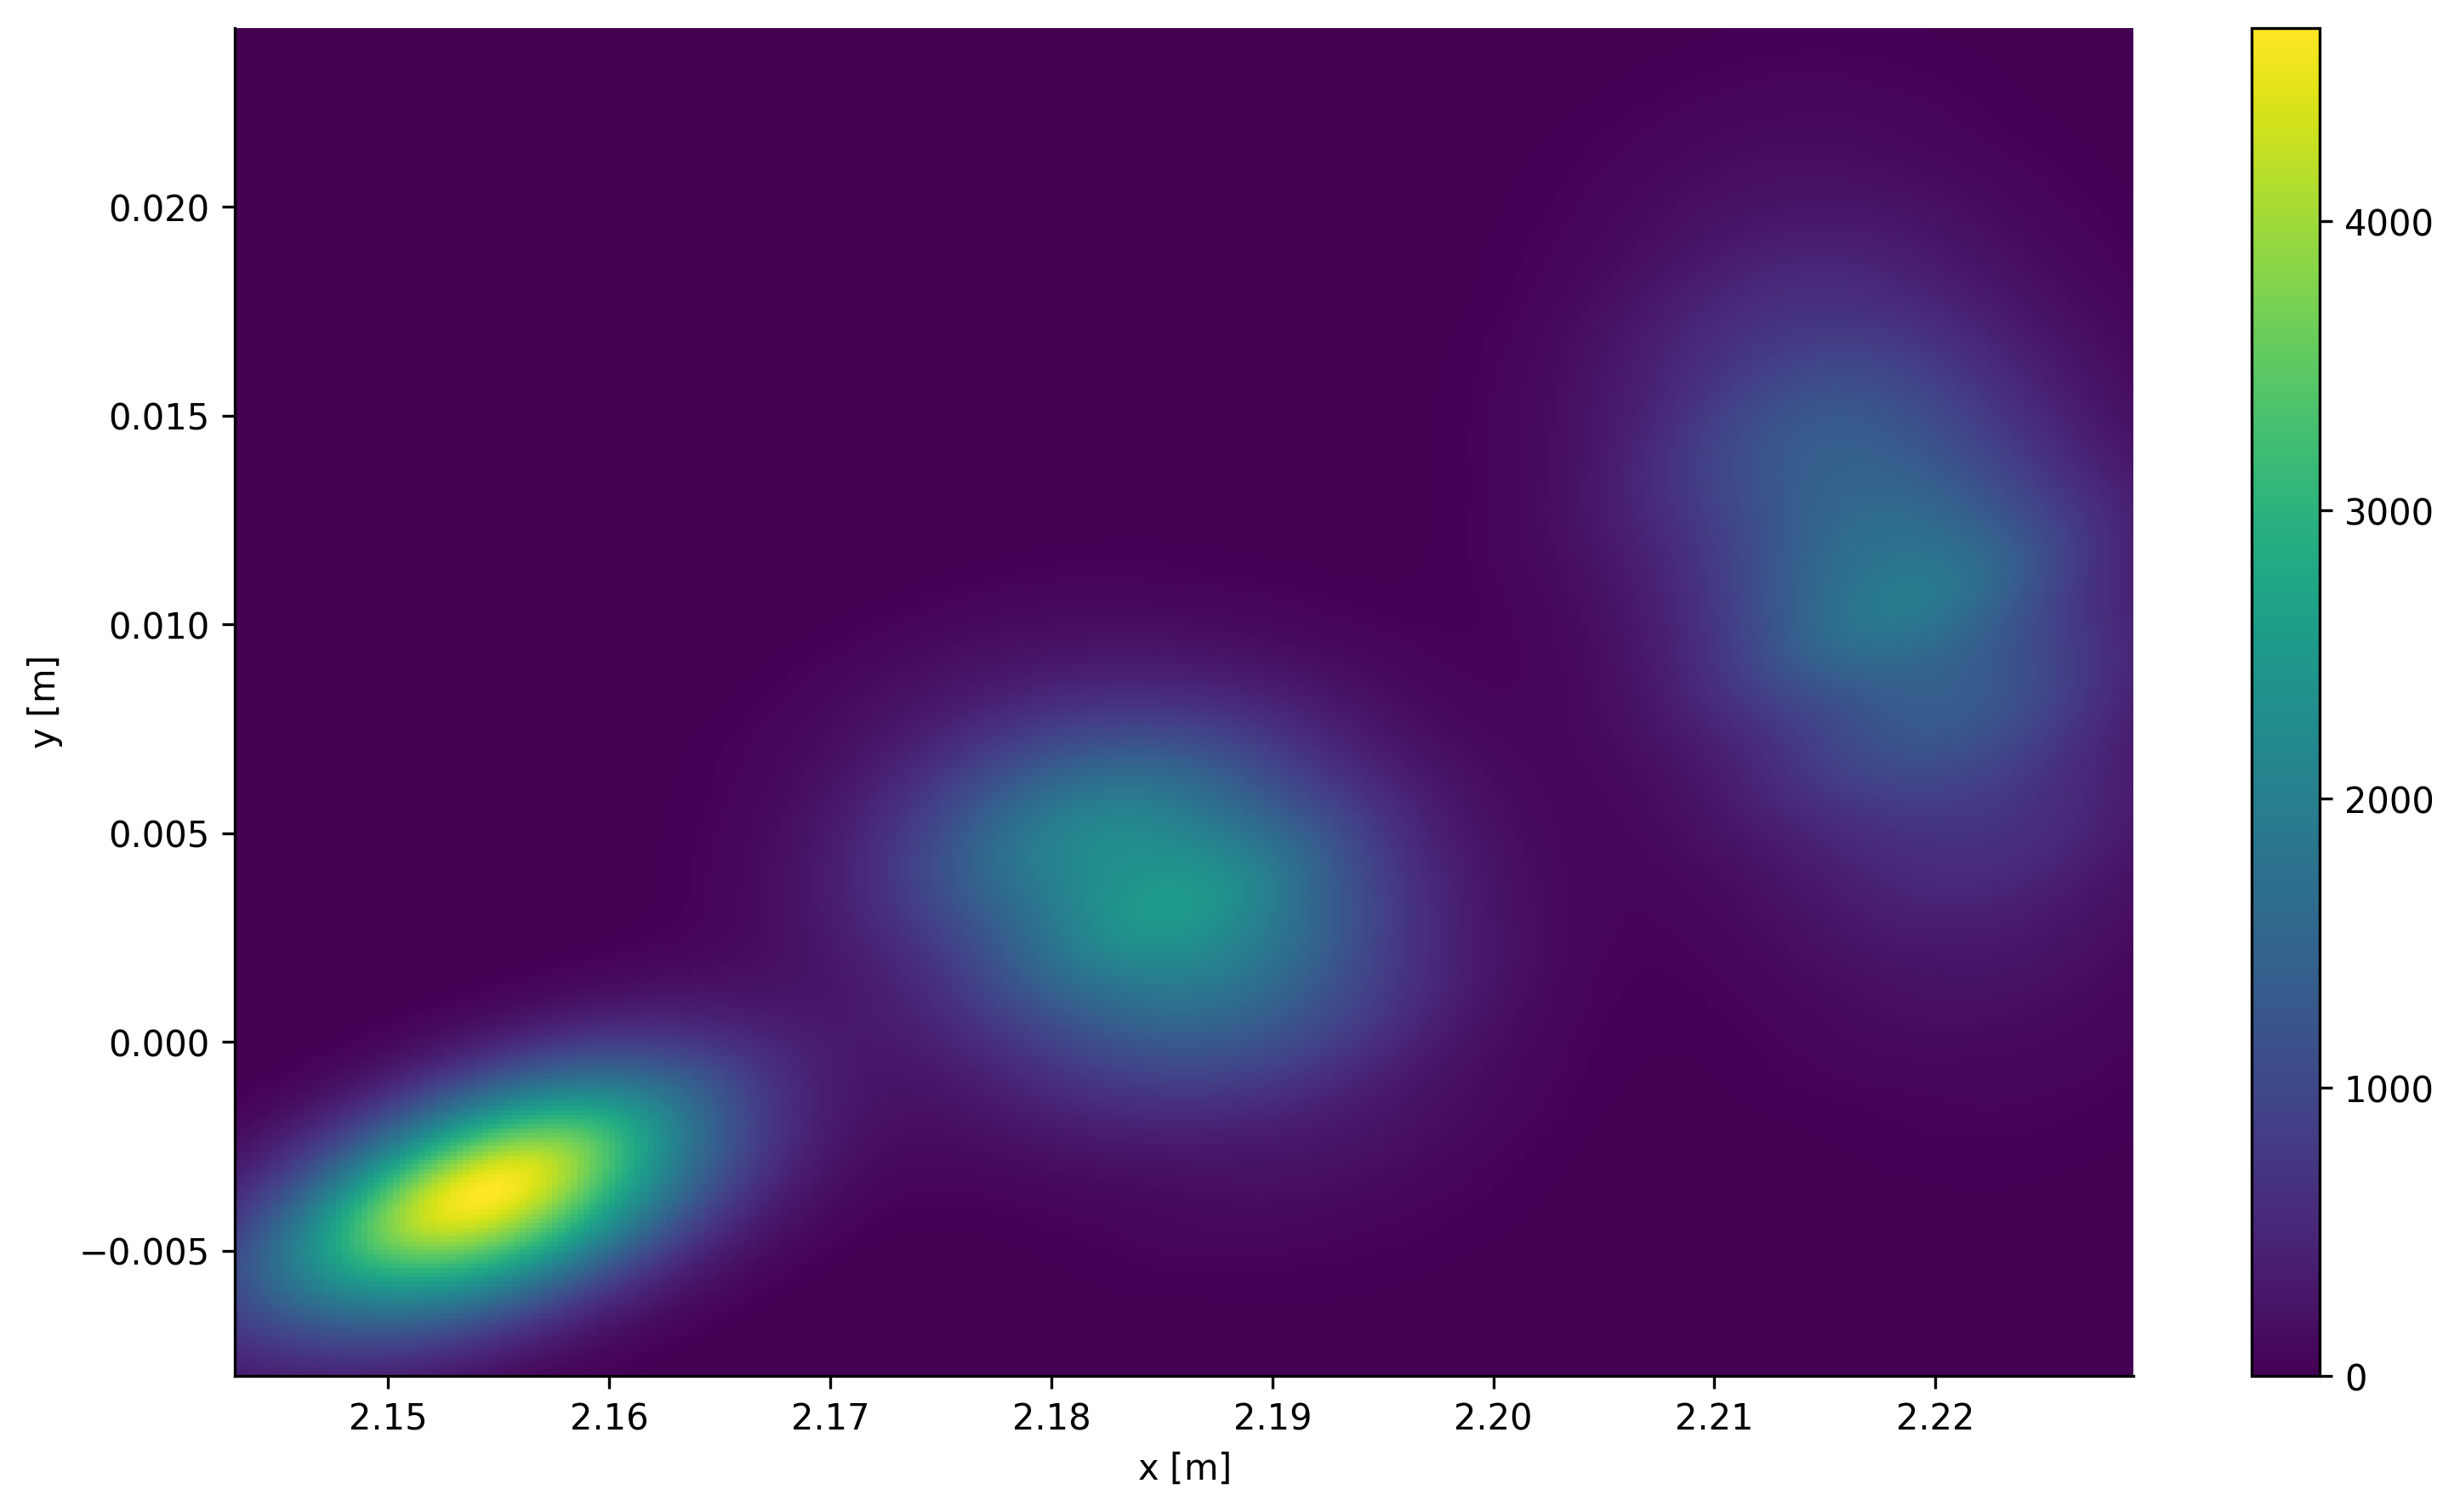

In [17]:
plt = ds.plot_density_scipy(xvar='x', yvar='y', step=3)

plt.show()

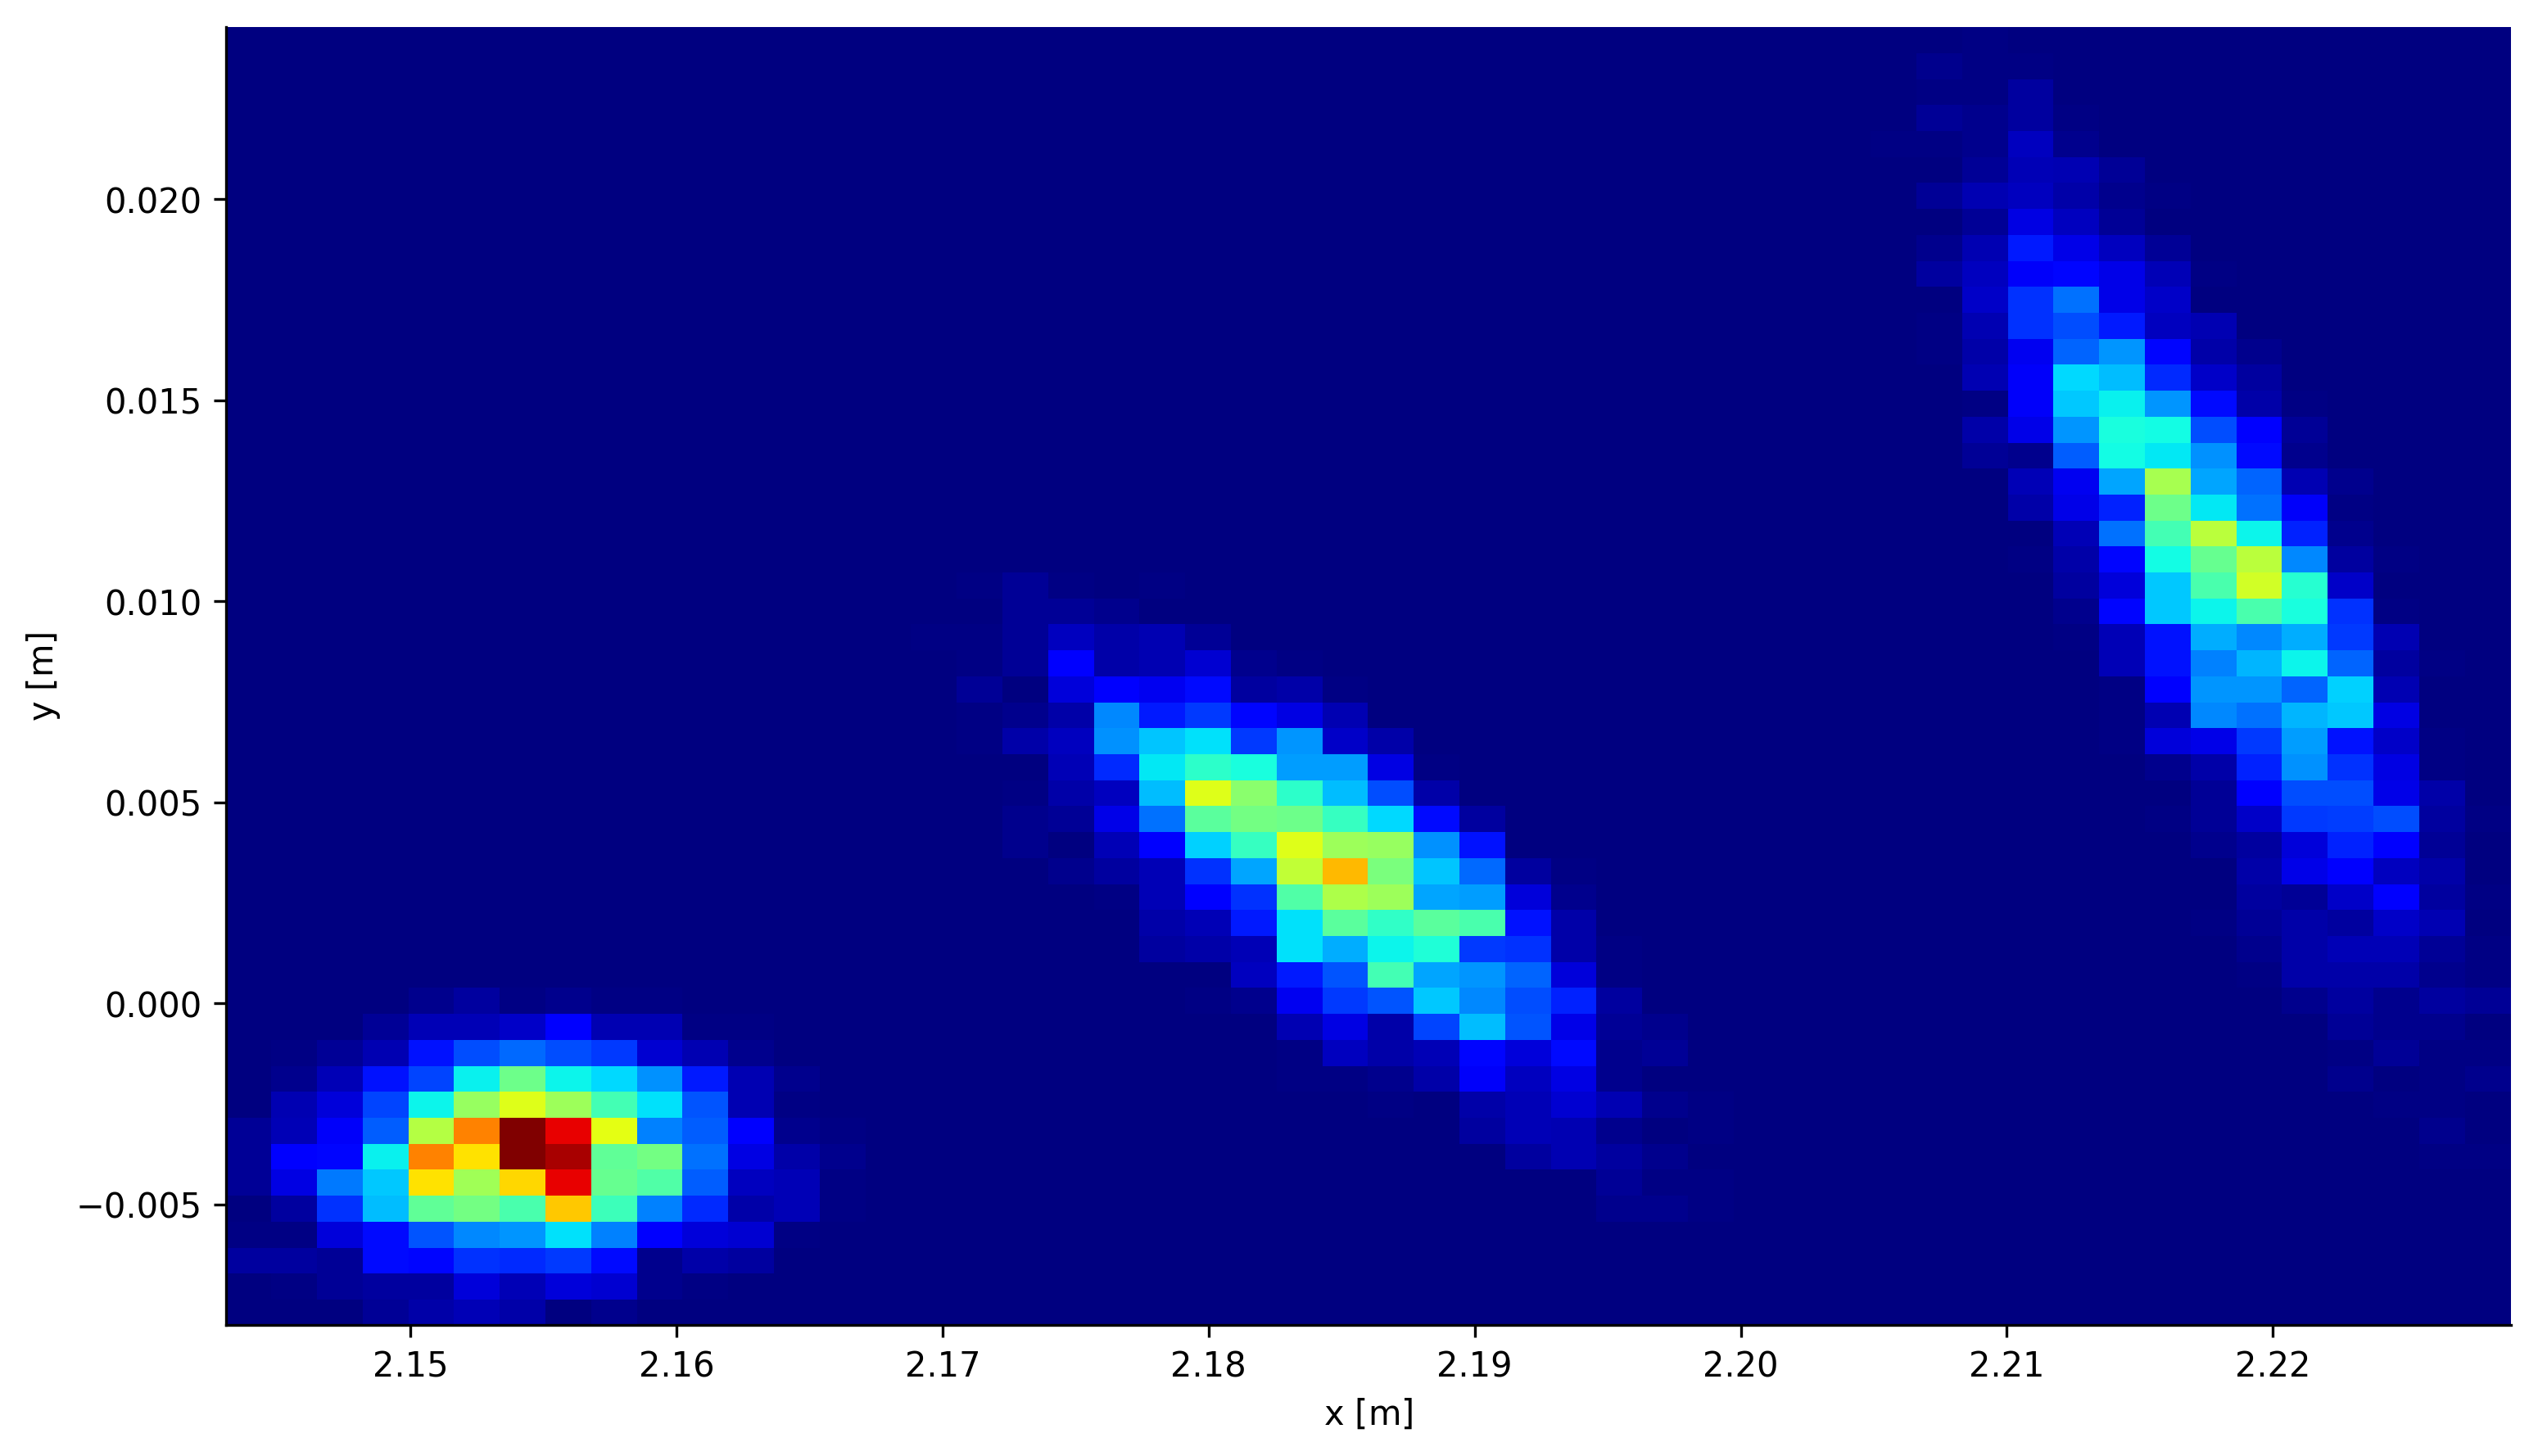

In [18]:
plt = ds.plot_density(xvar='x', yvar='y', step=3)

plt.show()